## Pima Indians Diabetes Dataset

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

[Link](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) to Kaggle repo.

**Features:** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Diabetes Pedigree Function, Age, Outcome


In [21]:
# Load PAckages Here
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import neighbors
from sklearn.naive_bayes import GaussianNB
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,79,33.6,0.627,50,1
1,1,85,66,29,79,26.6,0.351,31,0
2,8,183,64,20,79,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Exploratory Statistics

Create `Nutritional Status` feature based on BMI.

C:\Users\corbi\AppData\Local\Temp\ipykernel_35736\904840920.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Nutritional Status', palette='Set2')


<Axes: xlabel='Nutritional Status', ylabel='count'>

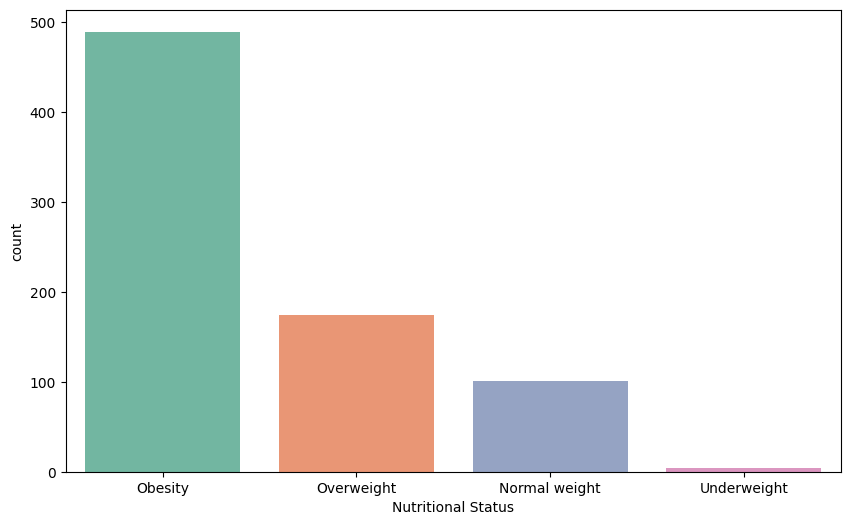

In [7]:
# Create `Nutritional Status` column based on BMI
def nutritional_status(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal weight'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obesity'
df['Nutritional Status'] = df['BMI'].apply(nutritional_status)

# Visualize the distribution of `Nutritional Status`
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Nutritional Status', palette='Set2')

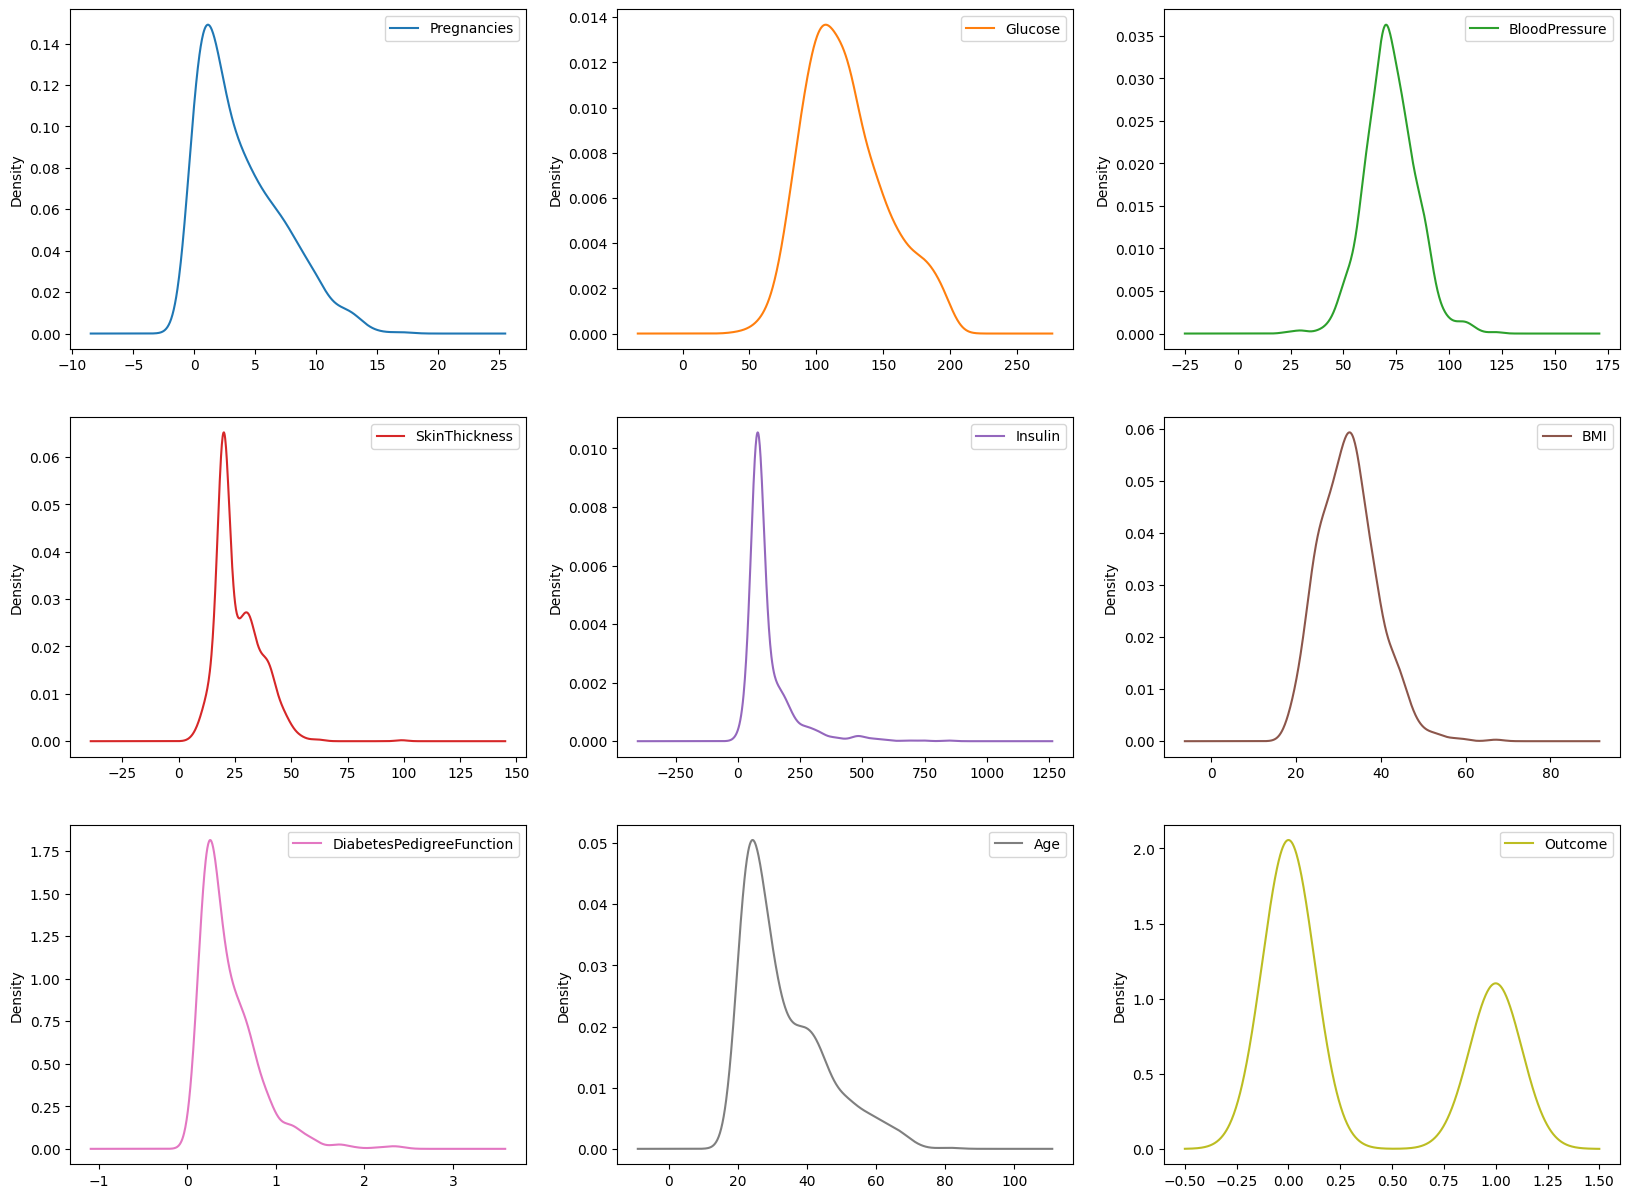

In [9]:
# Density plots for all attributes to visualize the distribution of each attribute
df.plot(kind='density', subplots=True, layout=(3,3), figsize=(20, 15), sharex=False)
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

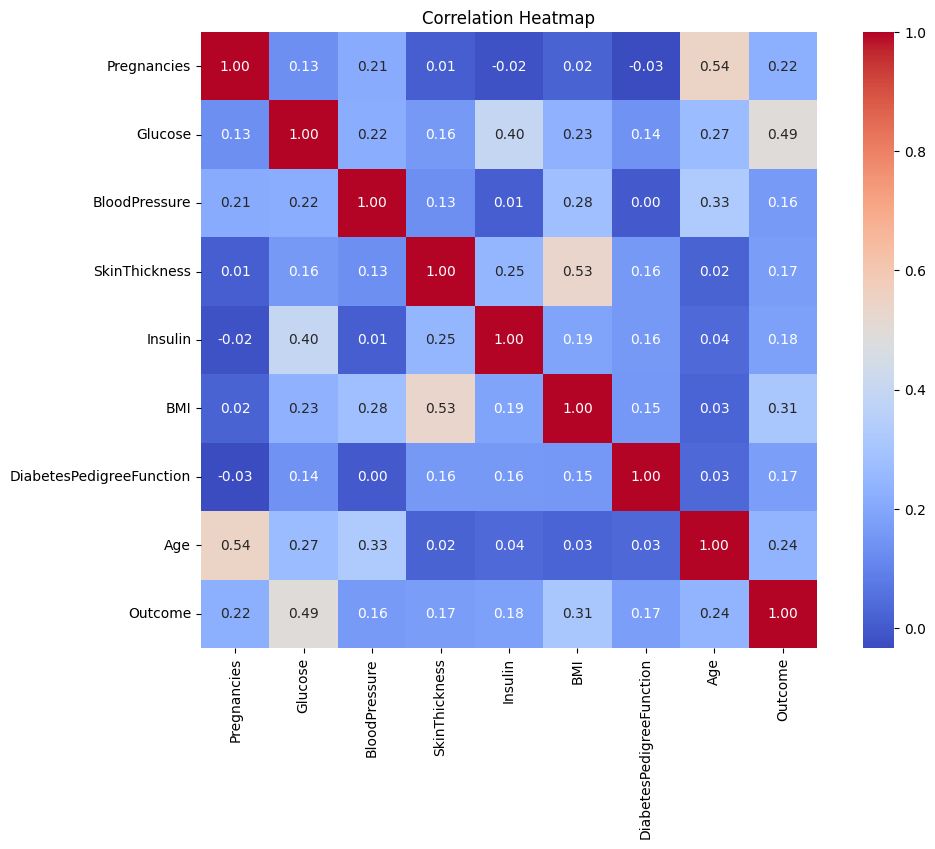

In [12]:
# Remove the `Nutritional Status` column for correlation analysis
df.drop(columns=['Nutritional Status'], inplace=True)

# Heatmap to visualize the correlation between attributes
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')

In [ ]:
# Divide the dataset into features and target variable
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



### K-Nearest Neighbor

In [ ]:
# Run the StandardScaler to standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN Classifier
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [16]:
# Chcek the accuracy of the model
accuracy = knn.score(X_test, y_test)
print(f'Accuracy of KNN Classifier: {accuracy:.2f}')

Accuracy of KNN Classifier: 0.75


Text(70.72222222222221, 0.5, 'Actual')

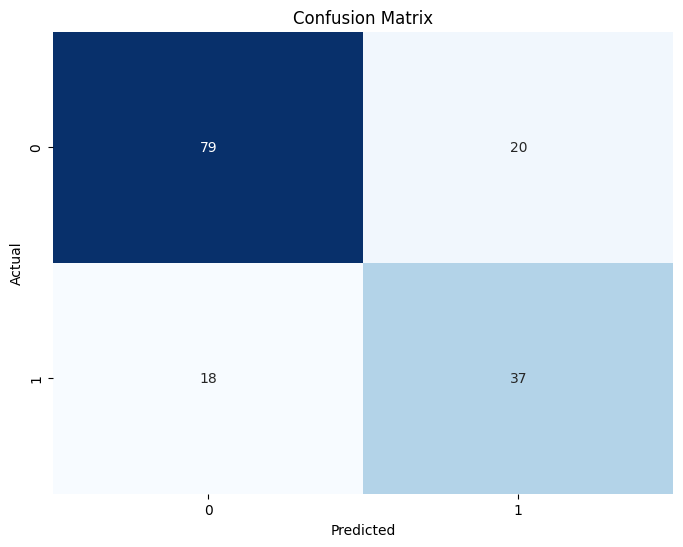

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

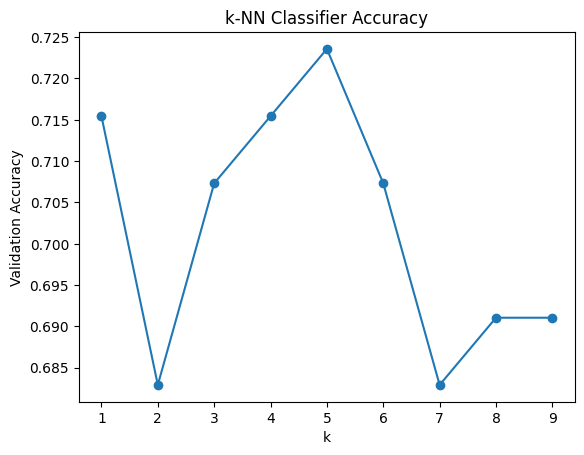

In [20]:
# Split the training data into a smaller training set and a validation set
X_train_subset, X_val_subset, y_train_subset, y_val_subset = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Iterate over different values of k and calculate validation accuracy
k_values = range(1, 10)
accuracies = []
for k in k_values:
    knn_model = neighbors.KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_subset, y_train_subset)
    y_pred_knn = knn_model.predict(X_val_subset)
    accuracy = np.mean(y_pred_knn == y_val_subset)
    accuracies.append(accuracy)

# Plot the validation accuracy for different k values
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('k-NN Classifier Accuracy')
plt.show()

### Bayesian Modeling

In [22]:
nb = GaussianNB()

# Fit the model
nb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb.predict(X_test)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy of Naive Bayes Classifier: {accuracy_nb:.2f}')

Accuracy of Naive Bayes Classifier: 0.75


Text(70.72222222222221, 0.5, 'Actual')

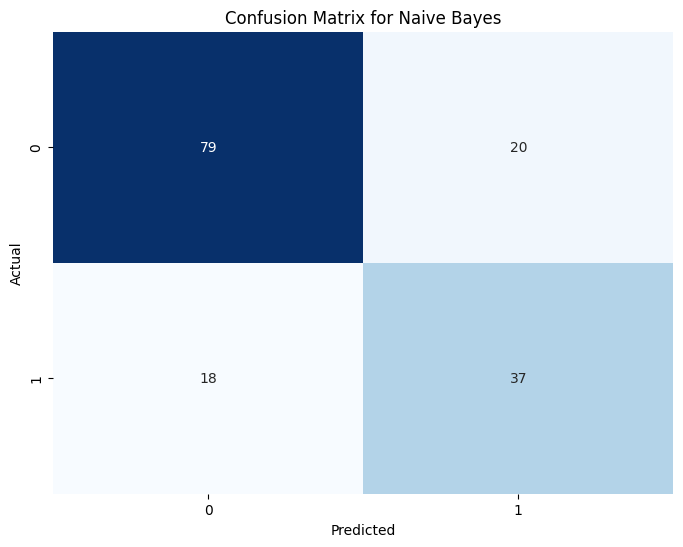

In [23]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')

(0.0, 1.0)

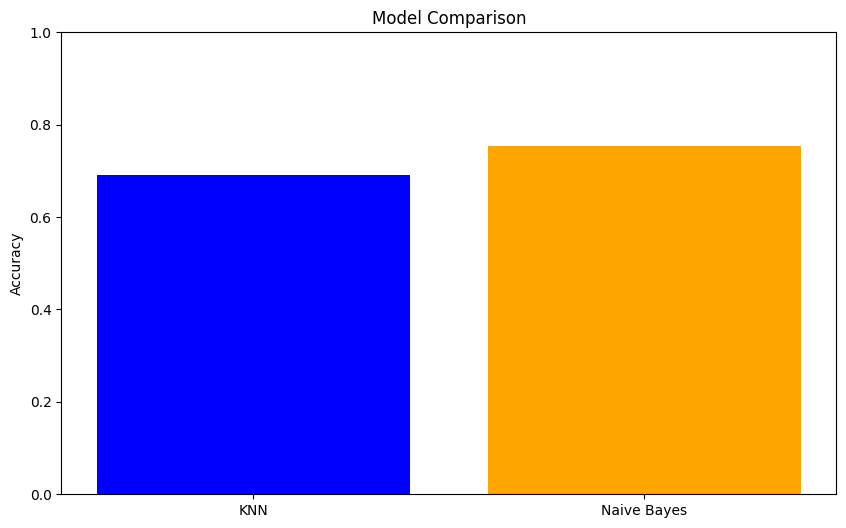

In [24]:
# Compare the two models
plt.figure(figsize=(10, 6))
plt.bar(['KNN', 'Naive Bayes'], [accuracy, accuracy_nb], color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)

Select on certain features, see if can improve accuracy by removing low-impct features such as age and pregnancie